# Data pipeline with keras and tf.data

The goal of this project is impelemente a data preprocessing pipeline using toolf from both Keras and tf.data module. Therefore I will use the ImageDataGenerator class in the tf.keras module to feed a network with trianing and test images from a local directory containing a subset of the LSUN dataset and train the model both with and without data augmentation. 

In [1]:
# Package and Libraries Imports

import tensorflow as tf
from tensorflow.keras.datasets import cifar100
import numpy as np
import matplotlib.pyplot as plt
import json

%matplotlib inline

##
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import image_dataset_from_directory
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D,Flatten, Dense, Input
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


![church](data/lsun/church.png) ![class](data/lsun/classroom.png) ![confe](data/lsun/conference_room.png)

## The LSUN Dataset

I will use a subset of the [LSUN dataset](https://www.yf.io/p/lsun). This is a large scale image dataset with 10 scene and 20 object categories.  The three classes included in the subset are `chruch_outdoor`, `classroom` and `conference_room`.

* F. Yu, A. Seff, Y. Zhang, S. Song, T. Funkhouser and J. Xia. "LSUN: Construction of a Large-scale Image Dataset using Deep Learning with Humans in the Loop". arXiv:1506.03365, 10 Jun 2015 


The goal is to use the Keras preprocessing tools to construct a data ingestion and augmentation pipeline to train a neural network to classify the iamges into the three classes.

In [2]:

train_dir = 'data/lsun/train'
valid_dir = 'data/lsun/valid'
test_dir = 'data/lsun/test'


### Creating the Data Generator using the ImageDataGenerator Class

In [3]:

def get_ImageDataGenerator():

    image_data_generator = ImageDataGenerator(rescale=1./255.)

    return image_data_generator


In [4]:
image_gen = get_ImageDataGenerator()


Function that returns a generator object that will yield batches of images and labels from the training and test set directories.

In [5]:

def get_generator(image_data_generator, directory, seed=None):
    generator = image_data_generator.flow_from_directory(
        directory=directory,
        target_size=(64,64),
        batch_size=20,
        class_mode='categorical',
        shuffle=True,
        seed=seed
    )

    return generator

In [6]:
train_generator = get_generator(image_gen, train_dir)
vallid_generator = get_generator(image_gen, valid_dir)

Found 300 images belonging to 3 classes.
Found 120 images belonging to 3 classes.


## Displaying Sample Images and labels from the training set

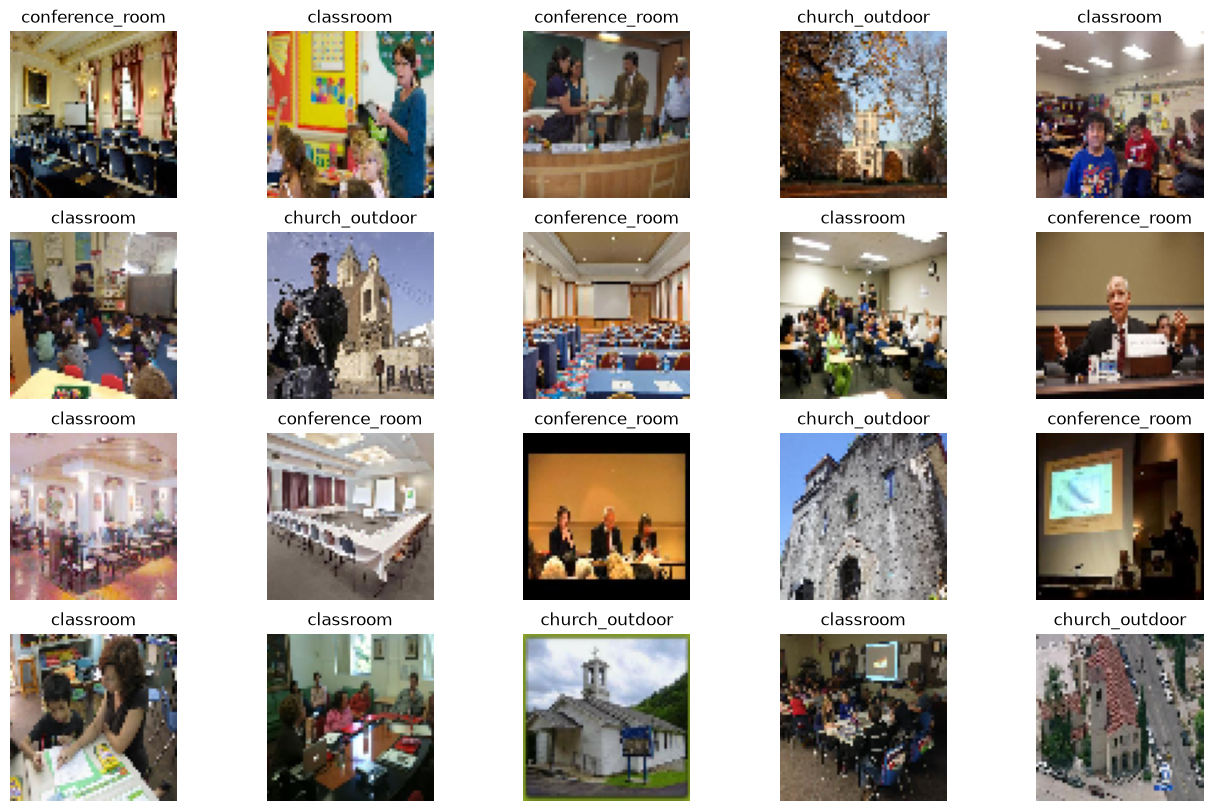

In [7]:
batch = next(train_generator)
batch_images = np.array(batch[0])
batch_labels = np.array(batch[1])
lsun_classes = ['church_outdoor', 'classroom', 'conference_room']


plt.figure(figsize=(16,10))
for i in range(20):
    ax = plt.subplot(4,5, i+1)
    plt.imshow(batch_images[i])
    plt.title(lsun_classes[np.where(batch_labels[i] == 1.)[0][0]])
    plt.axis('off')


In [8]:

train_generator = get_generator(image_gen, train_dir)

Found 300 images belonging to 3 classes.


## Building the Neural Network Model

In [9]:

def get_model(input_shape):

    inputs=Input(shape=input_shape)
    conv2d_1 = Conv2D(8, (8,8), padding='same', activation='relu')(inputs)
    maxpool1 = MaxPooling2D(pool_size=(2,2))(conv2d_1)
    conv2d_2 = Conv2D(4, (4,4), padding='same', activation='relu')(maxpool1)
    maxpool2 = MaxPooling2D(pool_size=(2,2))(conv2d_2)
    flatten = Flatten()(maxpool2)
    dense_1 = Dense(16, activation='relu')(flatten)
    outputs = Dense(3, activation='softmax')(dense_1)

    model = Model(inputs=inputs, outputs=outputs)

    optimizer = Adam(learning_rate=0.0005)

    model.compile(optimizer=optimizer, loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [10]:
lsun_model = get_model((64,64,3))
lsun_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 8)      │         1,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 4)      │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        16,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,511 (72.31 KB)

 Trainable params: 18,511 (72.31 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Neural Network Model

In [11]:

def train_model(model, train_gen, valid_gen, epochs):

    earlystopping = EarlyStopping(monitor='val_accuracy', patience=10)
    reduceLR = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                 min_lr=0.0001)

    history = model.fit(train_gen, validation_data=(valid_gen), epochs=epochs,
              callbacks=[earlystopping, reduceLR])

    return history


In [12]:
history = train_model(lsun_model, train_generator, vallid_generator,
                      epochs=50)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3333 - loss: 1.1095 - val_accuracy: 0.3833 - val_loss: 1.0884 - learning_rate: 5.0000e-04
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3933 - loss: 1.0761 - val_accuracy: 0.4000 - val_loss: 1.0774 - learning_rate: 5.0000e-04
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4833 - loss: 1.0440 - val_accuracy: 0.4417 - val_loss: 1.0241 - learning_rate: 5.0000e-04
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5567 - loss: 0.9670 - val_accuracy: 0.5500 - val_loss: 0.9546 - learning_rate: 5.0000e-04
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6333 - loss: 0.8531 - val_accuracy: 0.4917 - val_loss: 0.9523 - learning_rate: 5.0000e-04
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6667 - loss: 0.7781 - val_accuracy: 0.6333 - val_loss: 0.8104 - learning_rate: 5.0000e-04
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7433 

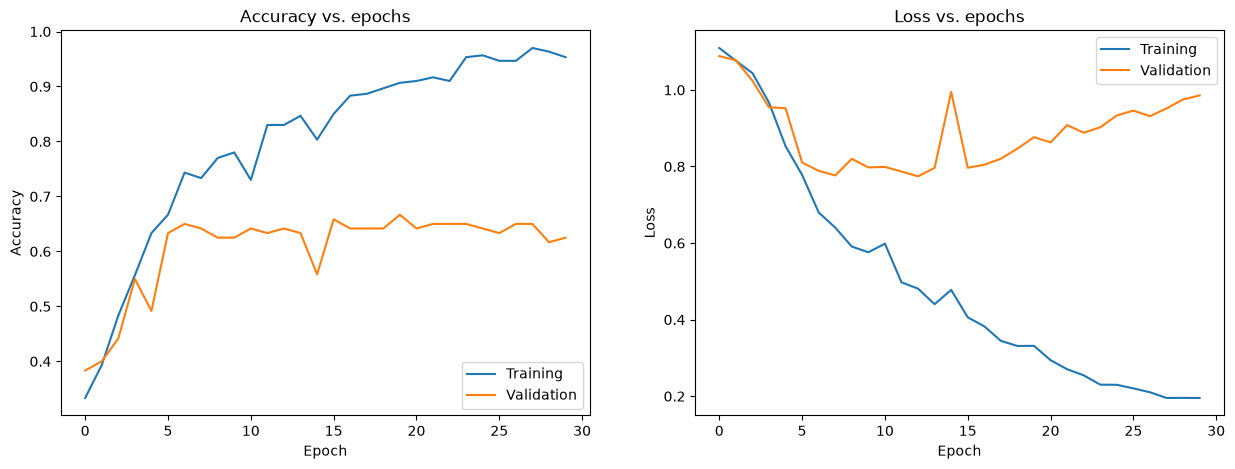

In [13]:

plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy vs. epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')

plt.subplot(122)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show() 

We can notice overfitting in the two plots, growing discrepancy between the training and validation loss and accuracy. One way to mitigate this is use data augmentation. Given a limited dataset, we can improve the performance by applying random modifications to the images in the trainig data.

# Creating a New Data Generator with Data Augmentation

In [14]:


def get_ImageDataGenerator_augmented():

    image_data_generator = ImageDataGenerator(rescale=1./255.,
                        rotation_range=30,
                        brightness_range=(0.5,1.5),
                        horizontal_flip = True)

    return image_data_generator

In [15]:
image_gen_aug = get_ImageDataGenerator_augmented()

In [16]:

valid_generator_aug = get_generator(image_gen_aug, valid_dir)
train_generator_aug = get_generator(image_gen_aug, train_dir, seed=10)

Found 120 images belonging to 3 classes.
Found 300 images belonging to 3 classes.


In [17]:

train_generator = get_generator(image_gen, train_dir, seed=10)

Found 300 images belonging to 3 classes.


# Displaying sample augmented images and labels from the training set

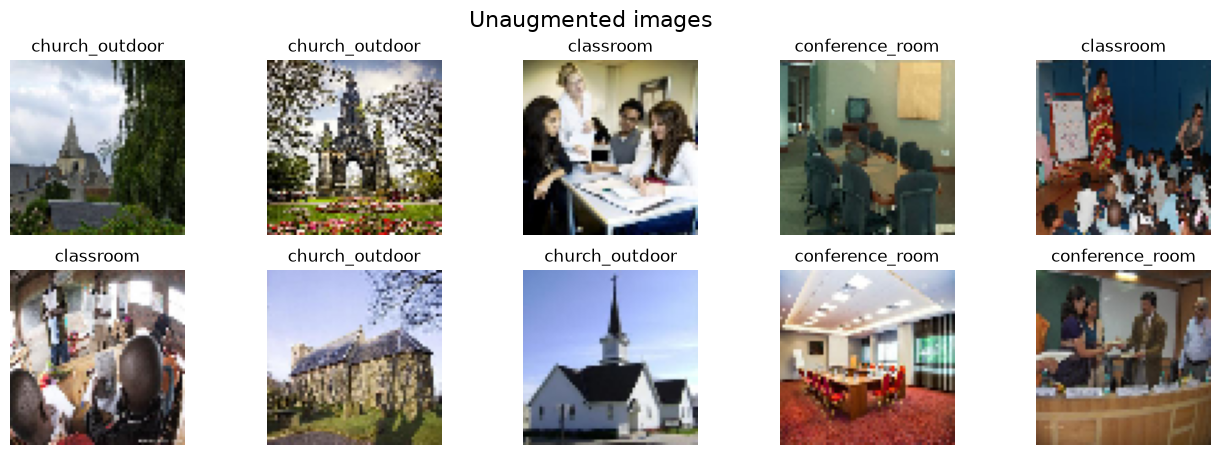

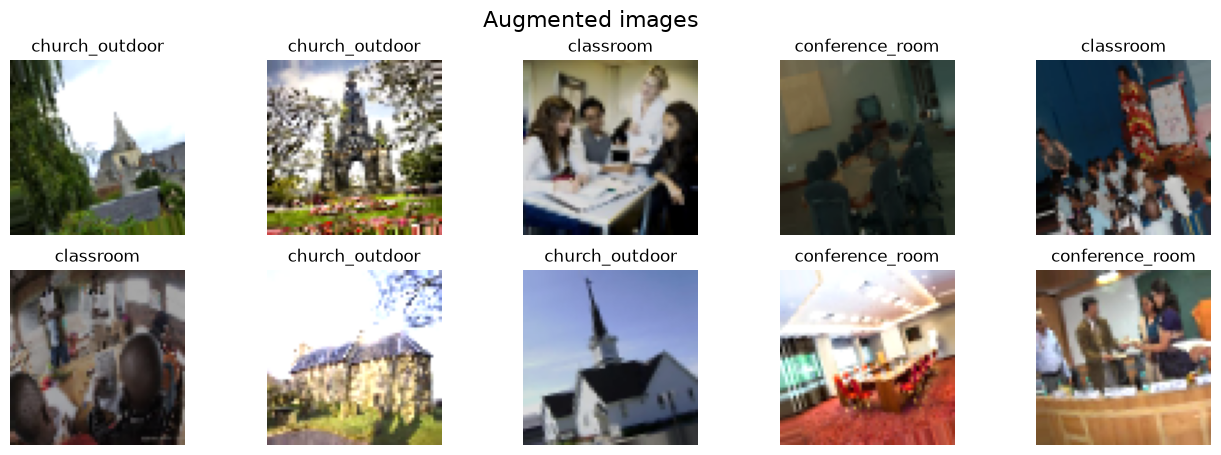

In [18]:
batch = next(train_generator)
batch_images = np.array(batch[0])
batch_labels = np.array(batch[1])

aug_batch = next(train_generator_aug)
aug_batch_images = np.array(aug_batch[0])
aug_batch_labels = np.array(aug_batch[1])

plt.figure(figsize=(16,5))
plt.suptitle("Unaugmented images", fontsize=16)
for n, i in enumerate(np.arange(10)):
    ax = plt.subplot(2, 5, n+1)
    plt.imshow(batch_images[i])
    plt.title(lsun_classes[np.where(batch_labels[i] == 1.)[0][0]])
    plt.axis('off')
plt.figure(figsize=(16,5))
plt.suptitle("Augmented images", fontsize=16)
for n, i in enumerate(np.arange(10)):
    ax = plt.subplot(2, 5, n+1)
    plt.imshow(aug_batch_images[i])
    plt.title(lsun_classes[np.where(aug_batch_labels[i] == 1.)[0][0]])
    plt.axis('off')


In [19]:

train_generator_aug = get_generator(image_gen_aug, train_dir)

Found 300 images belonging to 3 classes.


In [20]:

lsun_new_model = get_model((64,64,3))

In [21]:

history_augmented = train_model(lsun_new_model, train_generator_aug,
                                valid_generator_aug, epochs=50)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3067 - loss: 1.1085 - val_accuracy: 0.4083 - val_loss: 1.0968 - learning_rate: 5.0000e-04
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3967 - loss: 1.0955 - val_accuracy: 0.4083 - val_loss: 1.0882 - learning_rate: 5.0000e-04
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4067 - loss: 1.0848 - val_accuracy: 0.4333 - val_loss: 1.0729 - learning_rate: 5.0000e-04
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4933 - loss: 1.0617 - val_accuracy: 0.5500 - val_loss: 1.0266 - learning_rate: 5.0000e-04
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5833 - loss: 1.0074 - val_accuracy: 0.5667 - val_loss: 0.9394 - learning_rate: 5.0000e-04
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5100 - loss: 0.9856 - val_accuracy: 0.5250 - val_loss: 0.8906 - learning_rate: 5.0000e-04
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5300 

## Plotting yhe learning curves

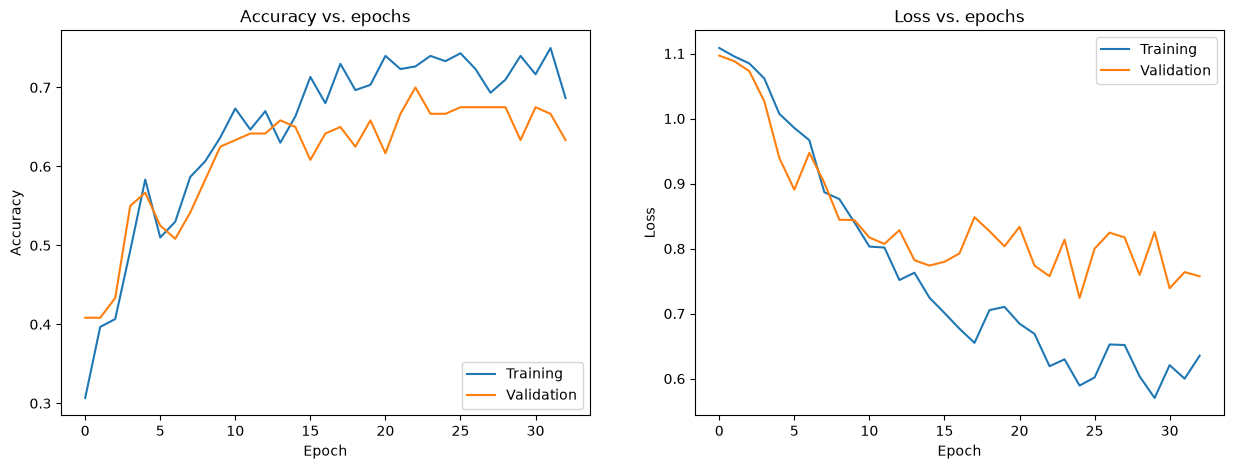

In [22]:
# Run this cell to plot accuracy vs epoch and loss vs epoch

plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(history_augmented.history['accuracy'])
plt.plot(history_augmented.history['val_accuracy'])

plt.title('Accuracy vs. epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')

plt.subplot(122)
plt.plot(history_augmented.history['loss'])
plt.plot(history_augmented.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show() 

We can see an improvement in the overfitting.

## Getting predictions using the trained model

In [23]:
num_batches= 3
seed = 25
test_generator = get_generator(image_gen_aug, test_dir, seed=seed)
predictions = lsun_new_model.predict(test_generator, steps=num_batches)

Found 300 images belonging to 3 classes.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


Found 300 images belonging to 3 classes.
[26 14 27 55]


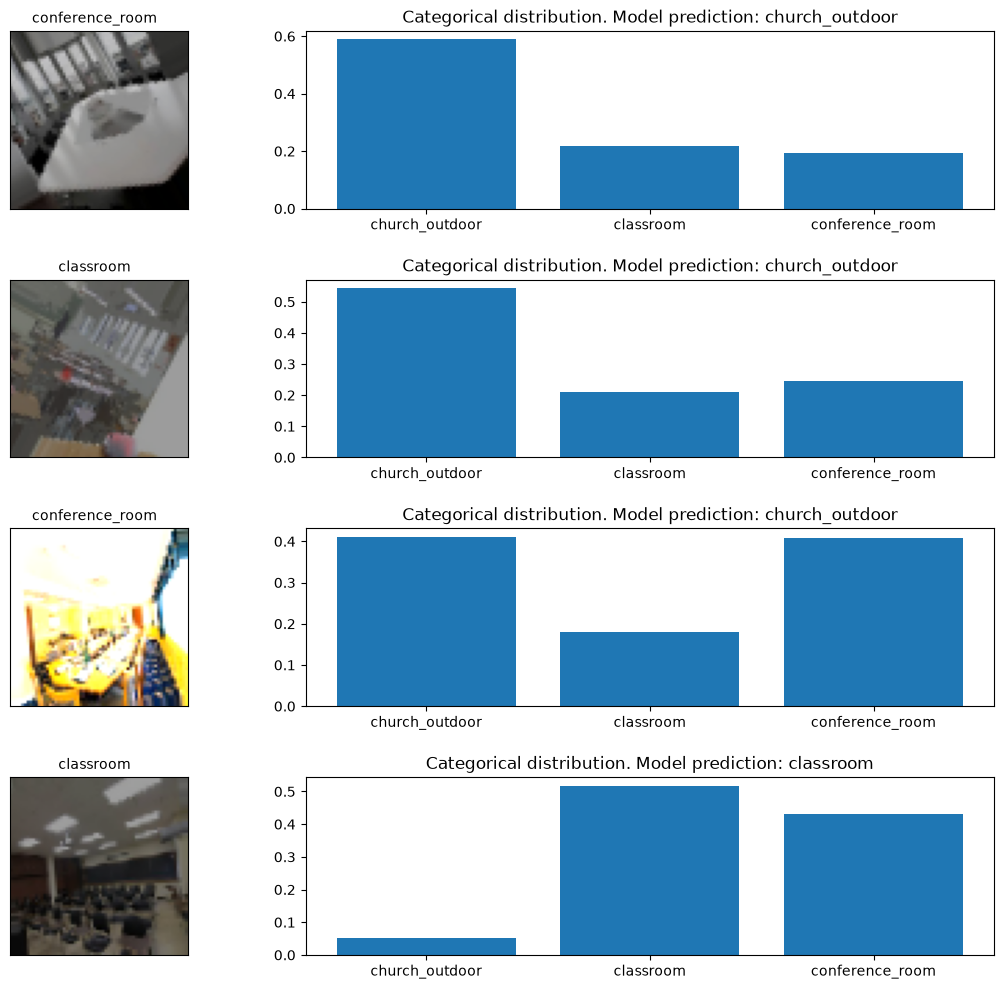

In [24]:

test_generator = get_generator(image_gen_aug, test_dir, seed=seed)
batches = []
for i in range(num_batches):
    batches.append(next(test_generator))
    
batch_images = np.vstack([b[0] for b in batches])
batch_labels = np.concatenate([b[1].astype(np.int32) for b in batches])

# Randomly select images from the batch
inx = np.random.choice(predictions.shape[0], 4, replace=False)
print(inx)

fig, axes = plt.subplots(4, 2, figsize=(16, 12))
fig.subplots_adjust(hspace=0.4, wspace=-0.2)

for n, i in enumerate(inx):
    axes[n, 0].imshow(batch_images[i])
    axes[n, 0].get_xaxis().set_visible(False)
    axes[n, 0].get_yaxis().set_visible(False)
    axes[n, 0].text(30., -3.5, lsun_classes[np.where(batch_labels[i] == 1.)[0][0]], 
                    horizontalalignment='center')
    axes[n, 1].bar(np.arange(len(predictions[i])), predictions[i])
    axes[n, 1].set_xticks(np.arange(len(predictions[i])))
    axes[n, 1].set_xticklabels(lsun_classes)
    axes[n, 1].set_title(f"Categorical distribution. Model prediction: {lsun_classes[np.argmax(predictions[i])]}")
    
plt.show()